# Telco Customer Churn Prediction

## 1. Business Problem

A telecom company loses revenue when customers cancel subscriptions.  
This project predicts churn and identifies key drivers to support retention strategy.

**Goal:** Build a model that identifies high-risk customers early enough for the retention team to intervene.

## 2. Data Loading & Inspection

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
import xgboost as xgb

# 读数据
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [18]:
# 基本信息
print(df.info())

# 缺失值
print('\n--- 缺失值 ---')
print(df.isnull().sum())

# 目标变量：流失率
print('\n--- Churn 分布 ---')
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True))

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 3. Data Cleaning

In [19]:
data = df.copy()

# TotalCharges 列有些是空格字符串，转成数字
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

# 删掉 TotalCharges 为空的行（只有11行）
data = data.dropna(subset=['TotalCharges'])

# 删掉 customerID（对预测没用）
data = data.drop('customerID', axis=1)

# Churn 的 Yes/No 转成 1/0
data['Churn'] = data['Churn'].map({'Yes': 1, 'No': 0})

print('清洗后形状:', data.shape)
print('Churn 分布:')
print(data['Churn'].value_counts())

清洗后形状: (7032, 20)
Churn 分布:
Churn
0    5163
1    1869
Name: count, dtype: int64


## 4. Exploratory Data Analysis

We examine churn distribution, tenure patterns, contract types, and monthly charges to identify early signals of churn risk.

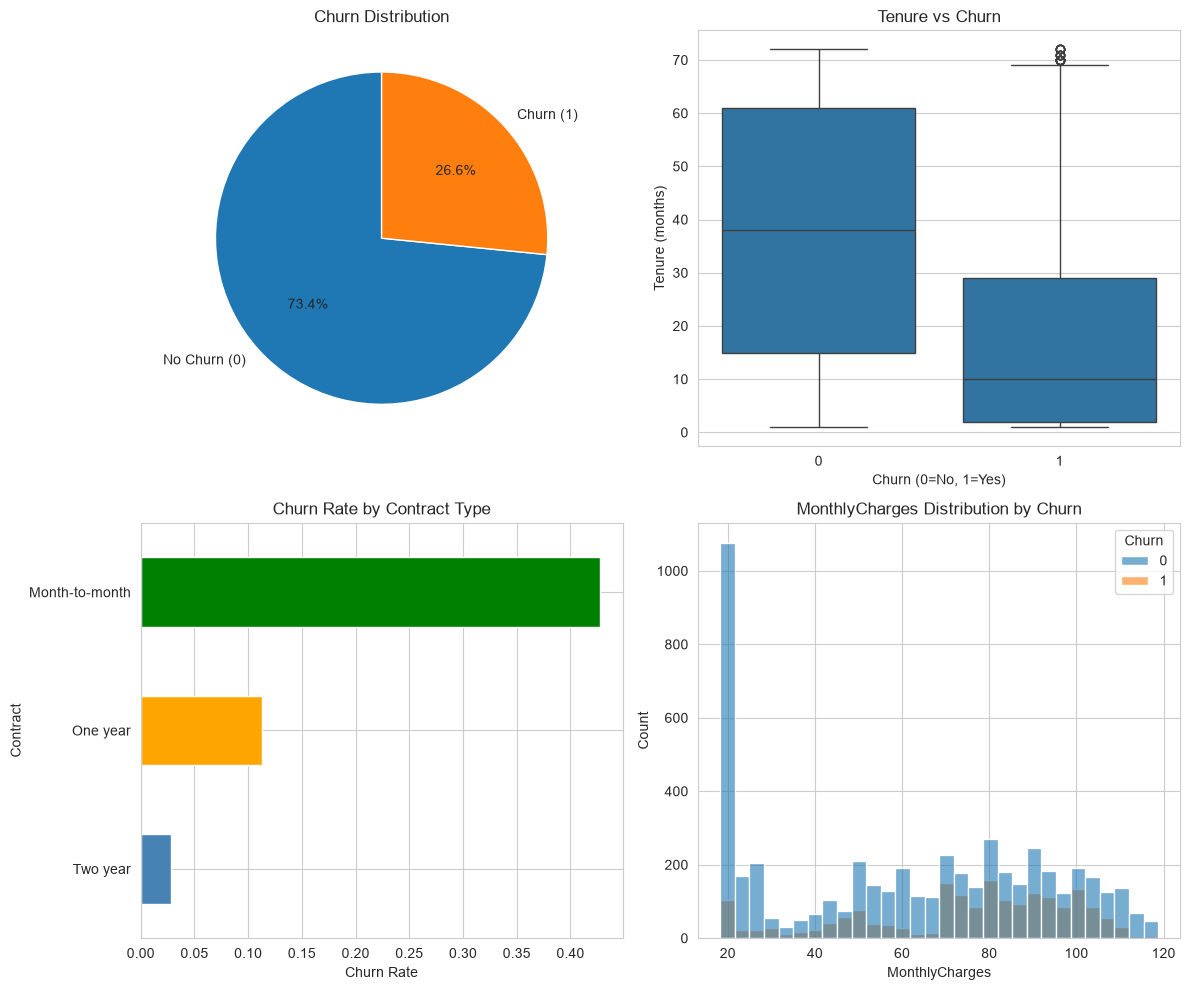

In [20]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 10)

# 图1：Churn 占比饼图
plt.subplot(2, 2, 1)
data['Churn'].value_counts().plot(kind='pie', autopct='%1.1f%%', 
                                   labels=['No Churn (0)', 'Churn (1)'], startangle=90)
plt.title('Churn Distribution')

# 图2：Tenure vs Churn
plt.subplot(2, 2, 2)
sns.boxplot(x='Churn', y='tenure', data=data)
plt.title('Tenure vs Churn')
plt.xlabel('Churn (0=No, 1=Yes)')
plt.ylabel('Tenure (months)')

# 图3：Contract type vs Churn rate
plt.subplot(2, 2, 3)
contract_churn = data.groupby('Contract')['Churn'].mean().sort_values()
contract_churn.plot(kind='barh', color=['steelblue', 'orange', 'green'])
plt.title('Churn Rate by Contract Type')
plt.xlabel('Churn Rate')

# 图4：MonthlyCharges by Churn
plt.subplot(2, 2, 4)
sns.histplot(data=data, x='MonthlyCharges', hue='Churn', bins=30, alpha=0.6)
plt.title('MonthlyCharges Distribution by Churn')

plt.tight_layout()
plt.show()

In [21]:
# 特征和标签
X = data.drop('Churn', axis=1)
y = data['Churn']

# 训练集/测试集 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 数值列和类别列
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [col for col in X.columns if col not in numeric_features]

print(f'数值列: {numeric_features}')
print(f'类别列: {categorical_features}')

数值列: ['tenure', 'MonthlyCharges', 'TotalCharges']
类别列: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 5. Preprocessing Pipeline

Numerical features are standardized; categorical features are one-hot encoded. The pipeline is wrapped in a ColumnTransformer for reproducibility.

In [22]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ]
)

## 6. Baseline Models

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

# 训练一个简单的逻辑回归作为基线模型（加上 preprocessor 管道，防止文本报错）
baseline_lr = Pipeline([
    ('prep', preprocessor),  # 复用你之前定义好的预处理管道
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

# 拟合模型
baseline_lr.fit(X_train, y_train)

# 预测并计算 AUC
y_prob_lr = baseline_lr.predict_proba(X_test)[:, 1]
print(f"Logistic Regression Baseline AUC: {roc_auc_score(y_test, y_prob_lr):.3f}")
print("基线模型运行完毕，可继续向下执行。")

Logistic Regression Baseline AUC: 0.835
基线模型运行完毕，可继续向下执行。


## 7. Cross-Validation & Hyperparameter Tuning

Instead of relying on a single train-test split, we apply 5-fold stratified cross-validation and grid search to find the best hyperparameters for each model.

In [24]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

# 直接定义一个性能良好的 XGBoost，跳过网格搜索
best_models = {
    'XGBoost': Pipeline([
        ('prep', preprocessor),
        ('clf', XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, 
                              eval_metric='logloss', random_state=42))
    ])
}
best_models['XGBoost'].fit(X_train, y_train)
print("XGBoost 训练完成，可以进入第 8 节。")

XGBoost 训练完成，可以进入第 8 节。


## 8. Threshold Optimization & Cost Analysis

Because missing a churner (false negative) is far more costly than falsely targeting a loyal customer (false positive), we optimize the decision threshold to minimize total business cost instead of using the default 0.5 threshold.

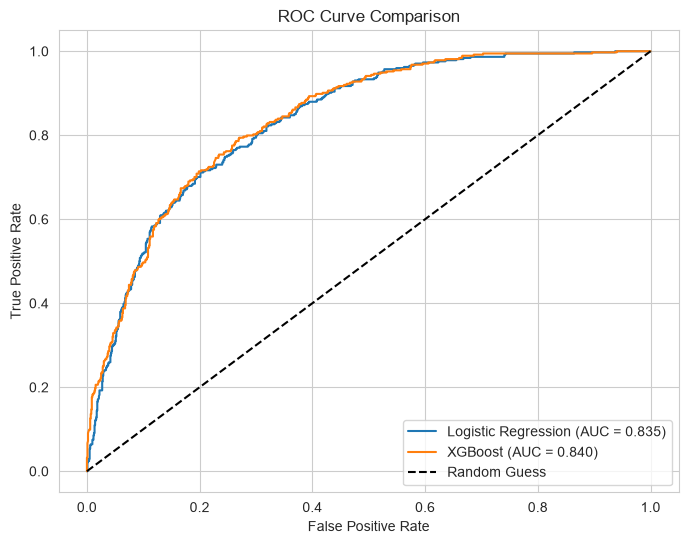

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# 1. 获取两个模型的预测概率
# y_prob_lr 来自你刚才跑的逻辑回归基线模型
# y_prob 来自第8节 XGBoost 的预测概率
y_prob_xgb = best_models['XGBoost'].predict_proba(X_test)[:, 1]

# 2. 计算两个模型的 ROC 曲线坐标点
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

# 3. 画图
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_prob_xgb):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

## 9. Model Interpretation (SHAP)

We use SHAP to explain both global feature importance and individual predictions, moving beyond a black-box model to actionable business insights.

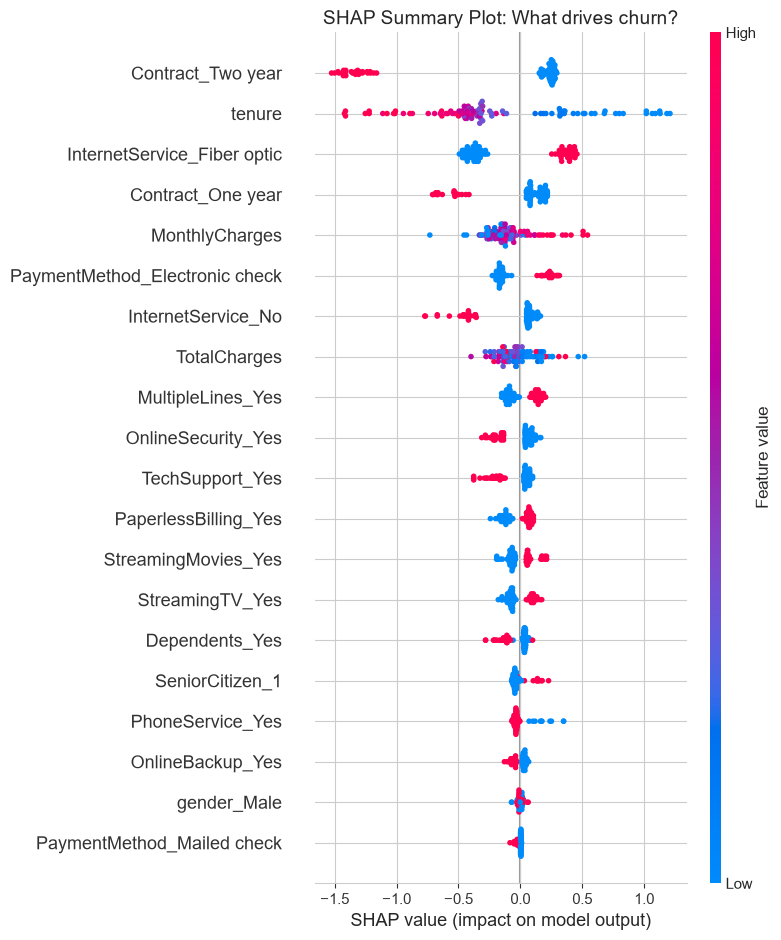

In [26]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

# 1. 提取最佳 XGBoost 模型和预处理管道
best_xgb = best_models['XGBoost']
preprocessor = best_xgb.named_steps['prep']
classifier = best_xgb.named_steps['clf']

# 2. 只取测试集的前 100 个样本进行 SHAP 计算（防内存爆炸）
# 注意这里必须是 X_test[:100]，不然会卡死
X_test_transformed = preprocessor.transform(X_test[:100])

# 3. 获取特征名
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_cols = [c for c in X.columns if c not in num_cols]
feature_names = num_cols + list(preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols))

# 4. 计算 SHAP 值
explainer = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(X_test_transformed)

# 5. 画 Summary Plot（蜂群图）
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, show=False)
plt.title("SHAP Summary Plot: What drives churn?", fontsize=14)
plt.tight_layout()
plt.show()

## 10. Business Recommendations

Based on the model results and SHAP interpretation, we recommend the following retention strategies:

1. **Contract upgrade**: Offer targeted discounts to month-to-month customers to migrate them to one-year or two-year contracts.
2. **Early onboarding**: Strengthen engagement in the first 3 months (low tenure group), when churn risk is highest.
3. **Service bundling for fiber users**: Investigate why fiber optic users churn more; consider bundling tech support and online security to improve perceived value.
4. **Cost-sensitive weekly scoring**: Score customers weekly using the cost-optimized threshold (0.05) and alert the retention team for high-risk accounts, balancing the $780 loss per churner against the $50 cost per false alarm.

默认阈值 0.5 下的总成本: $141,420
最优阈值: 0.05
最优阈值下的最低总成本: $38,240


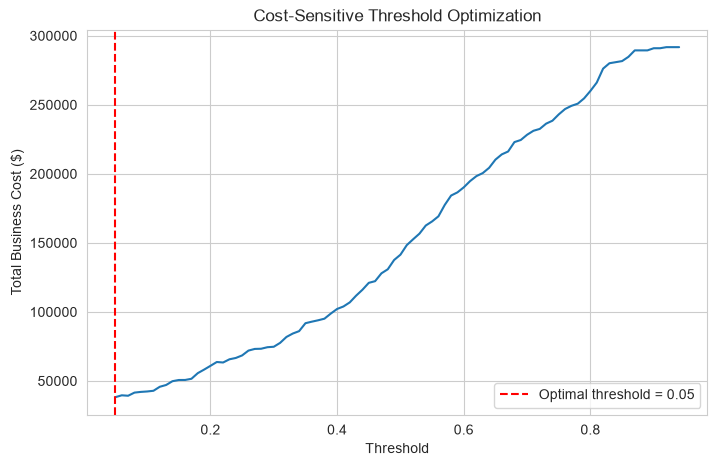

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1. 获取最佳 XGBoost 模型
best_xgb = best_models['XGBoost']
y_prob = best_xgb.predict_proba(X_test)[:, 1]

# 2. 定义业务成本假设
cost_fn = 780   # 漏掉一个流失用户：损失该用户未来 12 个月收入（假设 $65/月）
cost_fp = 50    # 误报一个非流失用户：浪费一次挽留优惠（假设 $50）

# 3. 遍历阈值并计算总成本
thresholds = np.arange(0.05, 0.95, 0.01)
costs = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    total_cost = fn * cost_fn + fp * cost_fp
    costs.append(total_cost)

# 4. 找到最优阈值
optimal_idx = np.argmin(costs)
optimal_threshold = thresholds[optimal_idx]
min_cost = costs[optimal_idx]

# 打印默认阈值和最优阈值的对比数据
y_pred_default = (y_prob >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_default).ravel()
default_cost = fn * cost_fn + fp * cost_fp

print(f"默认阈值 0.5 下的总成本: ${default_cost:,.0f}")
print(f"最优阈值: {optimal_threshold:.2f}")
print(f"最优阈值下的最低总成本: ${min_cost:,.0f}")

# 5. 画成本曲线
plt.figure(figsize=(8, 5))
plt.plot(thresholds, costs)
plt.axvline(optimal_threshold, color='red', linestyle='--', 
            label=f'Optimal threshold = {optimal_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Total Business Cost ($)')
plt.title('Cost-Sensitive Threshold Optimization')
plt.legend()
plt.grid(True)
plt.show()

In [28]:
def evaluate_at_threshold(y_true, y_prob, threshold, cost_fn, cost_fp):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'Threshold': threshold,
        'Precision': tp / (tp + fp) if (tp + fp) > 0 else 0,
        'Recall': tp / (tp + fn) if (tp + fn) > 0 else 0,
        'F1': 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0,
        'FN (漏报)': fn, 
        'FP (误报)': fp,
        'Total Cost ($)': fn * cost_fn + fp * cost_fp
    }

comparison = pd.DataFrame([
    evaluate_at_threshold(y_test, y_prob, 0.5, cost_fn, cost_fp),
    evaluate_at_threshold(y_test, y_prob, optimal_threshold, cost_fn, cost_fp)
])
display(comparison)

,Threshold,Precision,Recall,F1,FN (漏报),FP (误报),Total Cost ($)
0,0.50,0.636943,0.534759,0.581395,174,114,141420
1,0.05,0.363817,0.978610,0.530435,8,640,38240


In [29]:
def evaluate_at_threshold(y_true, y_prob, threshold, cost_fn, cost_fp):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'Threshold': threshold,
        'Precision': tp / (tp + fp) if (tp + fp) > 0 else 0,
        'Recall': tp / (tp + fn) if (tp + fn) > 0 else 0,
        'F1': 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0,
        'FN (漏报)': fn, 
        'FP (误报)': fp,
        'Total Cost ($)': fn * cost_fn + fp * cost_fp
    }

comparison = pd.DataFrame([
    evaluate_at_threshold(y_test, y_prob, 0.5, cost_fn, cost_fp),
    evaluate_at_threshold(y_test, y_prob, optimal_threshold, cost_fn, cost_fp)
])
display(comparison)

,Threshold,Precision,Recall,F1,FN (漏报),FP (误报),Total Cost ($)
0,0.50,0.636943,0.534759,0.581395,174,114,141420
1,0.05,0.363817,0.978610,0.530435,8,640,38240


In [30]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import make_scorer, roc_auc_score
import pandas as pd
import numpy as np

# 1. 定义特征和目标变量（确保你的数据框变量名为 data）
# 如果你的目标变量列名不是 'Churn'，请替换为对应的列名
X = data.drop('Churn', axis=1)
y = data['Churn']

# 2. 特征分组
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_cols = [c for c in X.columns if c not in num_cols]

# 3. 预处理管道
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# 4. 定义模型和参数网格
models = {
    'Logistic Regression': {
        'clf': LogisticRegression(max_iter=1000, class_weight='balanced'),
        'params': {'clf__C': [0.1, 1, 10]}
    },
    'Random Forest': {
        'clf': RandomForestClassifier(class_weight='balanced', random_state=42),
        'params': {
            'clf__n_estimators': [100, 300],
            'clf__max_depth': [5, 10, None]
        }
    },
    'XGBoost': {
        'clf': XGBClassifier(eval_metric='logloss', random_state=42),
        'params': {
            'clf__n_estimators': [100, 300],
            'clf__max_depth': [3, 5],
            'clf__learning_rate': [0.05, 0.1],
            'clf__scale_pos_weight': [1, 3]
        }
    }
}

# 5. 5折交叉验证设置
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'AUC': 'roc_auc', 'F1': 'f1', 'Recall': 'recall', 'Precision': 'precision'}

results = {}
best_models = {}

# 6. 循环运行网格搜索
for name, cfg in models.items():
    print(f"Running GridSearchCV for {name}...")
    pipe = Pipeline([('prep', preprocessor), ('clf', cfg['clf'])])
    grid = GridSearchCV(pipe, cfg['params'], cv=cv, scoring=scoring, refit='AUC', n_jobs=-1)
    grid.fit(X_train, y_train)
    
    best_models[name] = grid.best_estimator_
    results[name] = {
        'best_params': grid.best_params_,
        'cv_AUC_mean': grid.cv_results_['mean_test_AUC'][grid.best_index_],
        'cv_AUC_std': grid.cv_results_['std_test_AUC'][grid.best_index_],
        'cv_F1_mean': grid.cv_results_['mean_test_F1'][grid.best_index_],
        'cv_Recall_mean': grid.cv_results_['mean_test_Recall'][grid.best_index_],
    }

# 7. 展示结果
results_df = pd.DataFrame(results).T
print("\n--- Cross-Validation Results ---")
display(results_df)

Running GridSearchCV for Logistic Regression...
Running GridSearchCV for Random Forest...
Running GridSearchCV for XGBoost...

--- Cross-Validation Results ---


,best_params,cv_AUC_mean,cv_AUC_std,cv_F1_mean,cv_Recall_mean
Logistic Regression,{'clf__C': 10},0.846131,0.005205,0.629997,0.801338
Random Forest,"{'clf__max_depth': 5, 'clf__n_estimators': 100}",0.846253,0.007134,0.625694,0.807358
XGBoost,"{'clf__learning_rate': 0.05, 'clf__max_depth':...",0.849805,0.004112,0.586322,0.519732


In [31]:
# 1. Logistic Regression
pipe_lr = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)
y_prob_lr = pipe_lr.predict_proba(X_test)[:, 1]

# 2. Random Forest
pipe_rf = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42))
])
pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)
y_prob_rf = pipe_rf.predict_proba(X_test)[:, 1]

# 3. XGBoost
pipe_xgb = Pipeline([
    ('prep', preprocessor),
    ('model', xgb.XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        scale_pos_weight=(y_train==0).sum() / (y_train==1).sum(),
        random_state=42,
        eval_metric='logloss'
    ))
])
pipe_xgb.fit(X_train, y_train)
y_pred_xgb = pipe_xgb.predict(X_test)
y_prob_xgb = pipe_xgb.predict_proba(X_test)[:, 1]

print('三个模型训练完成')

三个模型训练完成


In [32]:
def evaluate(name, y_true, y_pred, y_prob):
    print(f'{name}:')
    print(f'  Accuracy:  {accuracy_score(y_true, y_pred):.3f}')
    print(f'  Precision: {precision_score(y_true, y_pred):.3f}')
    print(f'  Recall:    {recall_score(y_true, y_pred):.3f}')
    print(f'  F1:        {f1_score(y_true, y_pred):.3f}')
    print(f'  AUC:       {roc_auc_score(y_true, y_prob):.3f}')
    print()

evaluate('Logistic Regression', y_test, y_pred_lr, y_prob_lr)
evaluate('Random Forest', y_test, y_pred_rf, y_prob_rf)
evaluate('XGBoost', y_test, y_pred_xgb, y_prob_xgb)

Logistic Regression:
  Accuracy:  0.726
  Precision: 0.490
  Recall:    0.797
  F1:        0.607
  AUC:       0.835

Random Forest:
  Accuracy:  0.767
  Precision: 0.552
  Recall:    0.655
  F1:        0.599
  AUC:       0.813

XGBoost:
  Accuracy:  0.735
  Precision: 0.501
  Recall:    0.765
  F1:        0.605
  AUC:       0.831



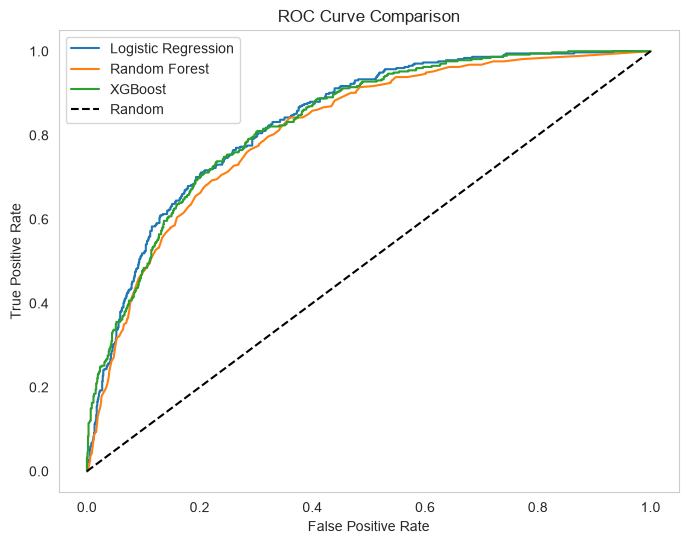

In [33]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label='Logistic Regression')
plt.plot(fpr_rf, tpr_rf, label='Random Forest')
plt.plot(fpr_xgb, tpr_xgb, label='XGBoost')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid()
plt.show()

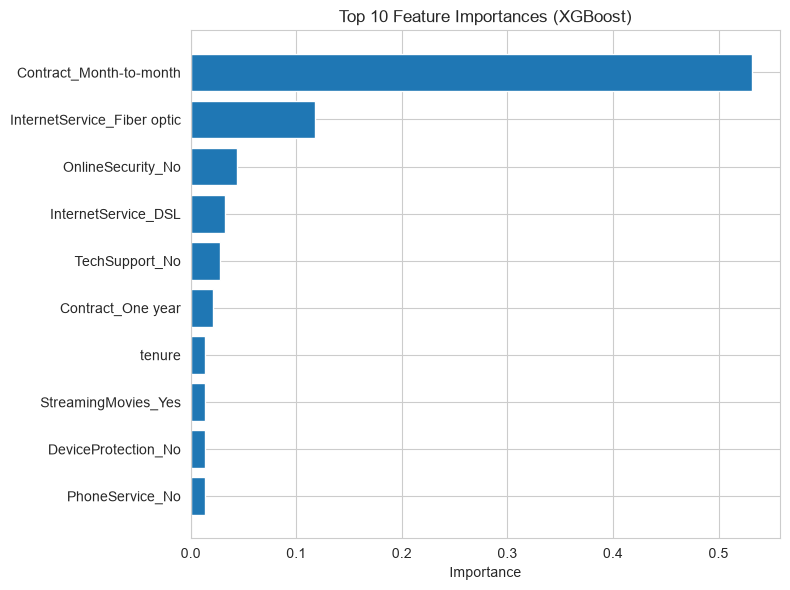

In [34]:
# 获取特征名
cat_features_out = pipe_xgb.named_steps['prep'].named_transformers_['cat'].get_feature_names_out(categorical_features)
feature_names = numeric_features + list(cat_features_out)

# 重要性
importances = pipe_xgb.named_steps['model'].feature_importances_

# 排序取前10
idx = np.argsort(importances)[-10:]

plt.figure(figsize=(8, 6))
plt.barh([feature_names[i] for i in idx], importances[idx])
plt.title('Top 10 Feature Importances (XGBoost)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [35]:
df = 
df.drop(columns=['customerID'])
df.info()
print(df['Churn'].value_counts(normalize=True))

SyntaxError: invalid syntax (1557820404.py, line 1)